## Notebook 2 - Analysis

### Objective
Analyse cancer incidence patterns among children and young people (CYP) aged 0–24
in England using validated NHS NDRS data, addressing three analytical questions:

1. How do overall cancer incidence and cancer type composition vary across age
   groups from infancy to young adulthood?
2. How does cancer incidence vary geographically across NHS England regions,
   and how does this picture change when adjusted for population size?
3. Which age groups, cancer types, and NHS England regions experienced the most
   notable changes in cancer incidence between 2013 and 2022?

### Input
Validated parquet files produced in Notebook 01 — Data Validation:
- `national_validated.parquet` — England-level incidence data, age groups 0–24,
  NDRS cancer group classification, 2013–2022
- `regional_validated.parquet` — NHS England region-level incidence data,
  aggregated to 0–24 age group, NDRS cancer group classification, 2013–2022
- `icd10_regional_rates_validated.parquet` — supplementary ICD-10 regional
  age-specific rates (C00-C97 excl. C44), used for population-adjusted
  regional comparison only

### Output
- Analytical charts for each of the three business questions (Sections 1–3)
- Key findings summary (Section 4)
- Limitations and methodological notes (Section 5)
- Charts exported to `3_output/3_images/` for use in the Power BI dashboard
  and one-page insight summary

### Import Dataset and Libraries

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# File paths
DATA_PATH = Path("../0_data/1_validated")

# Load validated datasets
national_df = pd.read_parquet(DATA_PATH / "national_validated.parquet")
regional_df = pd.read_parquet(DATA_PATH / "regional_validated.parquet")
icd10_df = pd.read_parquet(DATA_PATH / "icd10_regional_rates_validated.parquet")

print("Dataset loaded successfully.")

Dataset loaded successfully.


All datasets loaded from validated parquet files produced in Notebook 1. Analysis uses counts throughout for national and regional NDRS data due to high rate suppression (11,869 of 15,480 national records and 13,292 of 18,090 regional records have suppressed rates). Rate-based analysis uses the supplementary ICD-10 dataset where all 90 records have published rates.

In [2]:
# Global styling settings
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Colour palette
NAVY = "#1F4E79"
TEAL = "#2E75B6"
LIGHT_BLUE = "#BDD7EE"
GREY = "#AAAAAA"

### 1. Age Profiles and Cancer Type Composition
- 1.1 Overall cancer type distribution
- 1.2 Age group distribution
- 1.3 Cancer composition by age group

#### 1.1 Overall cancer type distribution

- Top 15 NDRS main cancer types across all age groups, from 2013 to 2022

In [3]:
# Plot data - top 15 NDRS main cancer types

top15_national = (
    national_df
    .groupby("NDRS main", observed=True)
    .agg(
        total_cases=("Count", "sum")
    )
    .sort_values("total_cases", ascending=False)
    .reset_index()
    .head(15)
)

top15_national

,NDRS main,total_cases
0,Blood cancer,26948
1,Brain,15100
2,Skin cancer,5908
3,Endocrine glands excluding brain,4758
4,Testes,4454
5,Soft tissue sarcoma,4410
6,Bone sarcoma,3508
7,Ovary,2582
8,Kidney,2126
9,Bowel,1696


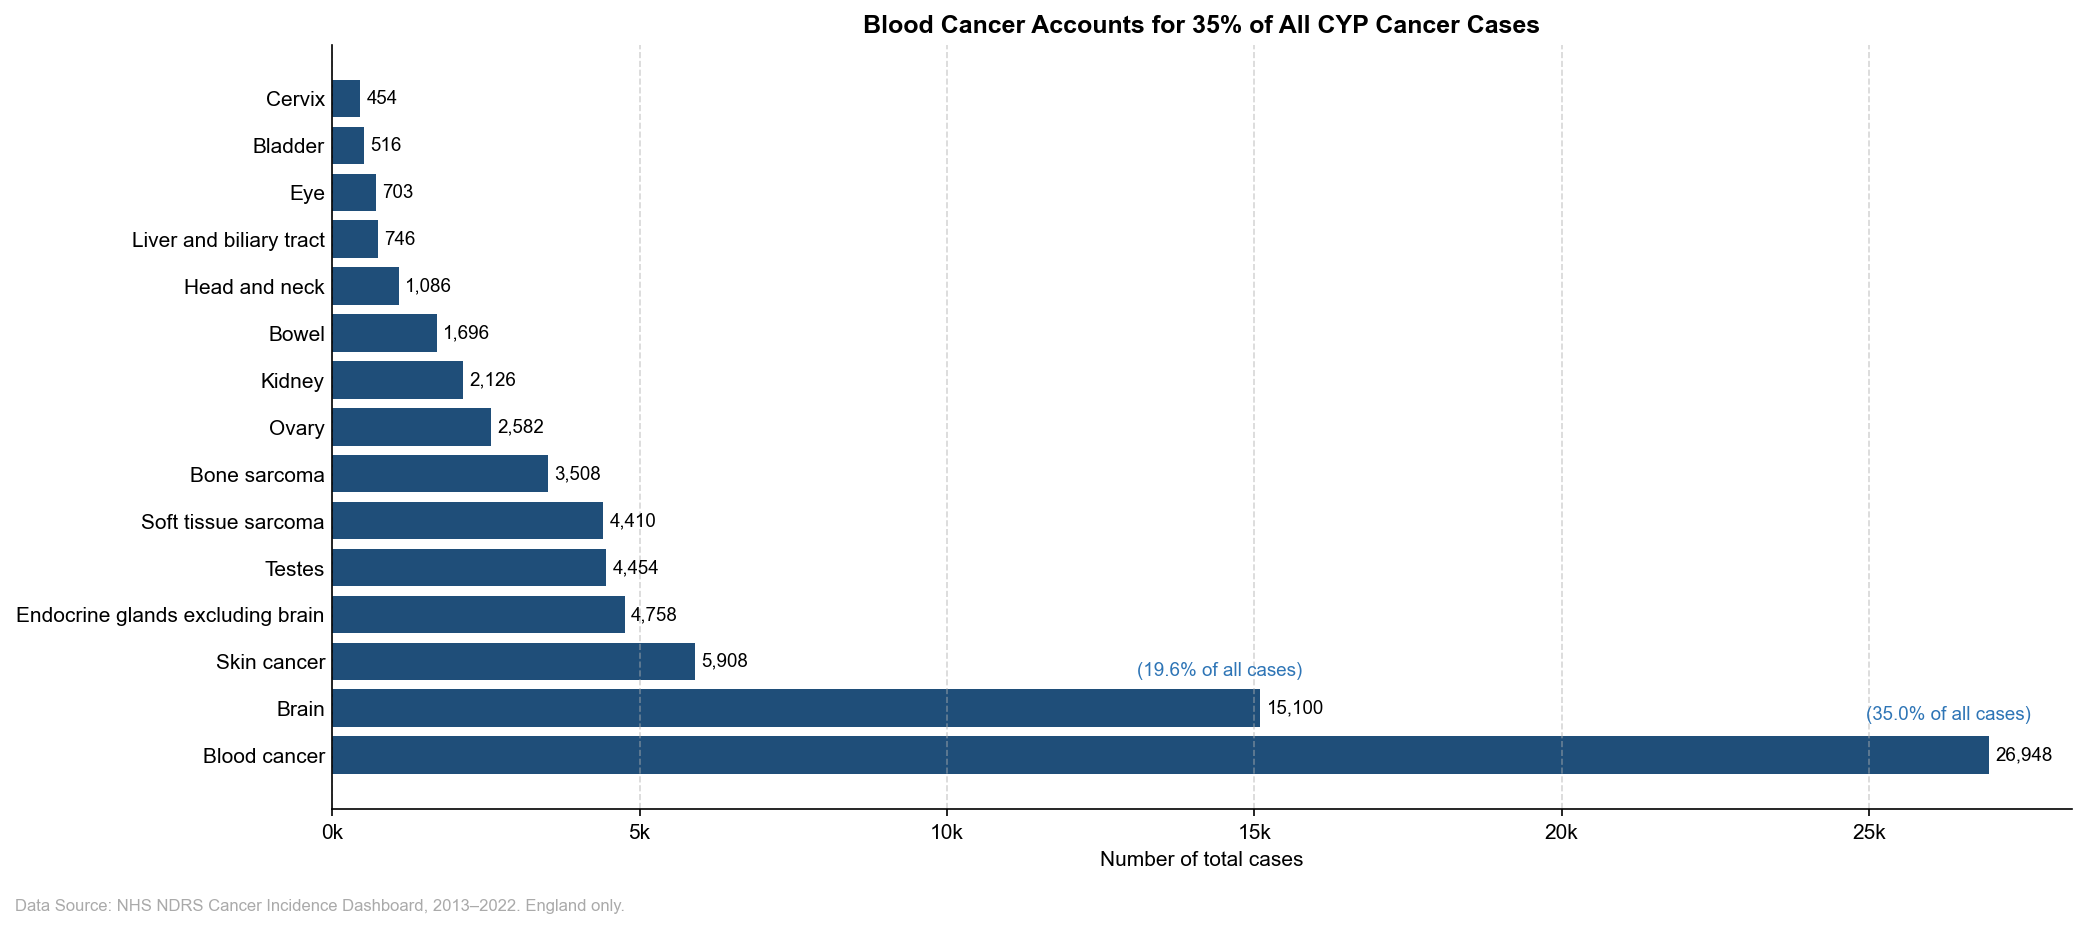

In [4]:
# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    top15_national["NDRS main"],
    top15_national["total_cases"],
    color=NAVY,
)

# Title and Labels
ax.set_title("Blood Cancer Accounts for 35% of All CYP Cancer Cases", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of total cases", fontsize=10)
fig.text(
    0.01, -0.02,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8,
    color=GREY,
    transform=fig.transFigure
)

# Formats
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
)
ax.tick_params(axis="y", length=0)


# Blood cancer annotation
blood_cancer_cases = top15_national[
    top15_national["NDRS main"] == "Blood cancer"
]["total_cases"].values[0]

total_all_cancers = national_df["Count"].sum()
blood_pct = blood_cancer_cases / total_all_cancers * 100

ax.annotate(
    f"({blood_pct:.1f}% of all cases)",
    xy=(blood_cancer_cases, 0),
    xytext=(blood_cancer_cases - 2000, 0.75),
    fontsize=9,
    color=TEAL
)

# Brain cancer annotation
brain_cancer_cases = top15_national[
    top15_national["NDRS main"] == "Brain"
]["total_cases"].values[0]

brain_pct = brain_cancer_cases / total_all_cancers *100

ax.annotate(
    f"({brain_pct:.1f}% of all cases)",
    xy=(brain_cancer_cases, 0),
    xytext=(brain_cancer_cases - 2000, 1.7),
    fontsize=9,
    color=TEAL
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/1_1_cancer_type_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- Blood cancer is by far the most common cancer type among children and young people in England, accounting for 35.0% of all cases recorded between 2013 and 2022. Brain cancer is the second most common at 19.6%. Together these two types account for over half of all CYP cancer cases.
- The remaining cancer types each account for less than 8% individually, with a long tail of rare types such as Mesothelioma (8 cases) and Anus (3 cases) representing extremely small numbers where statistical interpretation requires caution.

#### 1.2 Age Group Distribution

In [5]:
# Plot data

total_cases_by_age_group = (
    national_df
    .groupby("Age at diagnosis", observed=True)
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

total_cases_by_age_group

,Age at diagnosis,total_cases
0,0 (Under 1),3158
1,01 to 04,11471
2,05 to 09,9017
3,10 to 14,9866
4,15 to 19,15875
5,20 to 24,27649


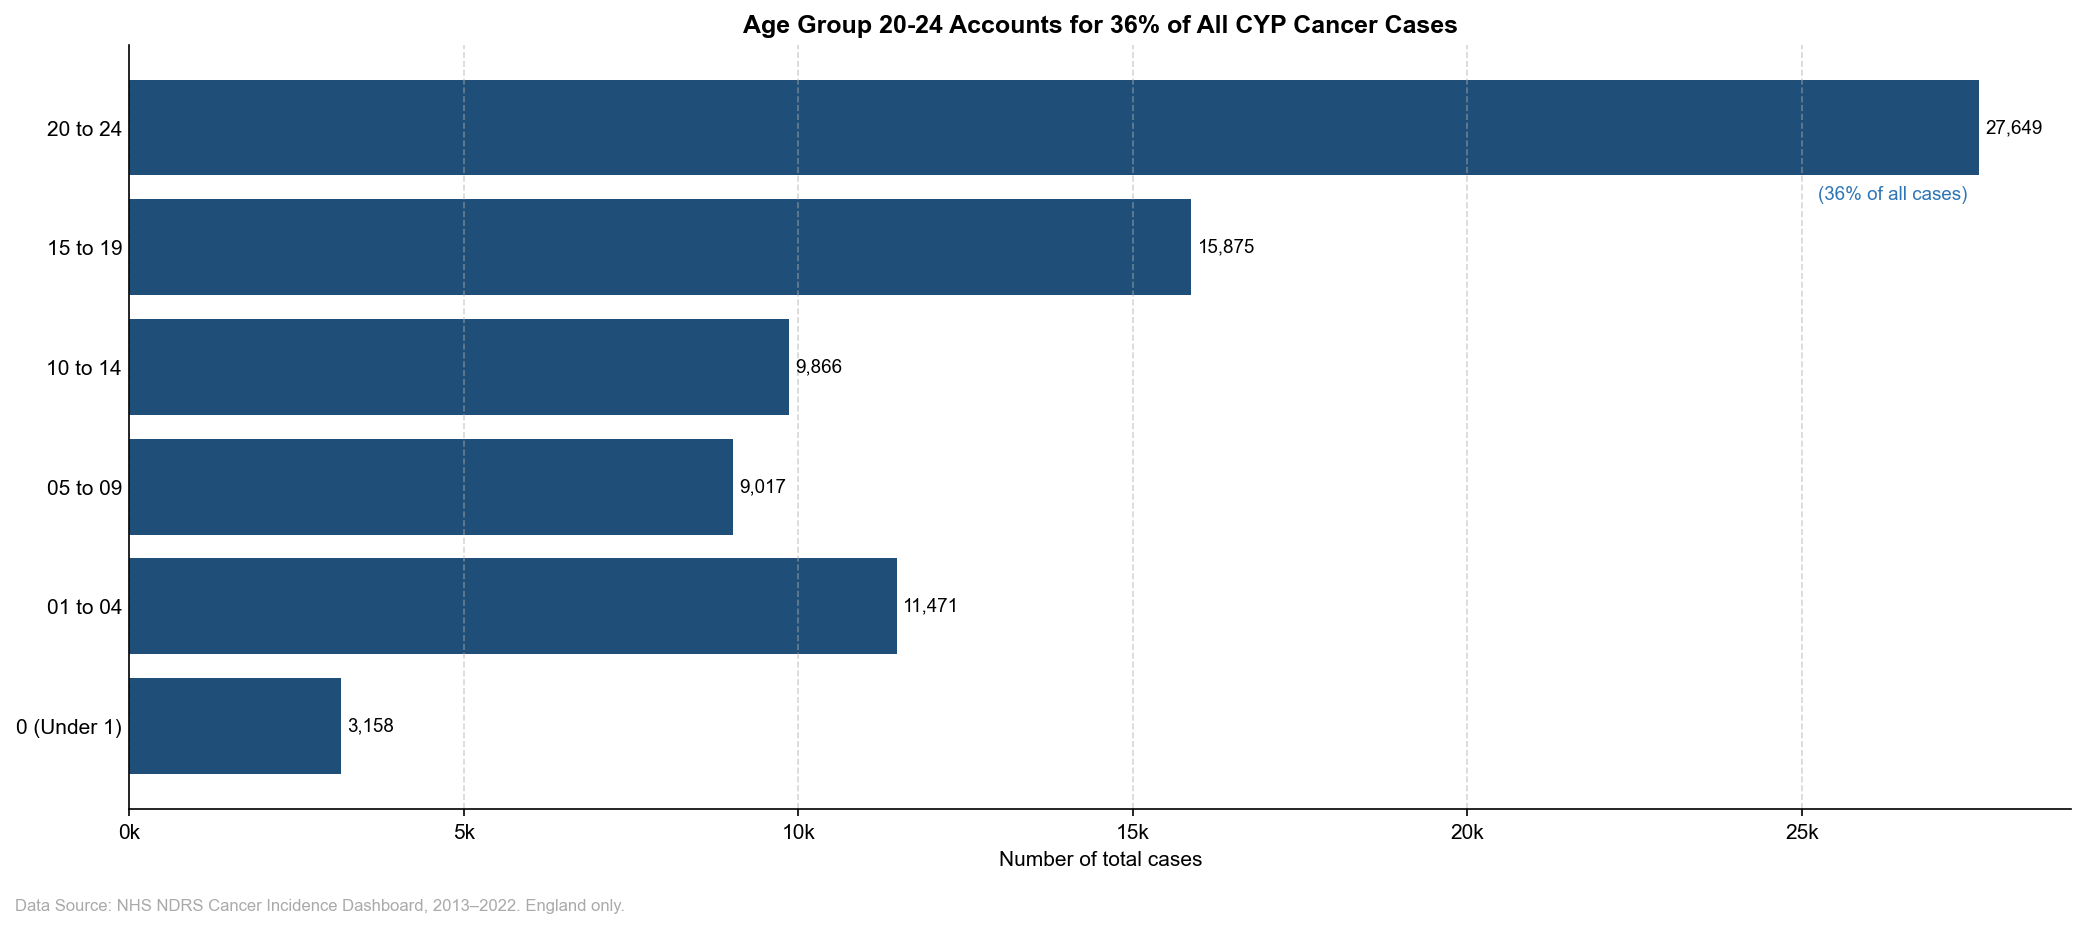

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    total_cases_by_age_group["Age at diagnosis"],
    total_cases_by_age_group["total_cases"],
    color=NAVY,
)

# Title and Labels
ax.set_title("Age Group 20-24 Accounts for 36% of All CYP Cancer Cases", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of total cases", fontsize=10)
fig.text(
    0.01, -0.02,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8,
    color=GREY,
    transform=fig.transFigure
)

# Formats
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
)
ax.tick_params(axis="y", length=0)

# 20-24 age group annotation
total_all_cancers = national_df["Count"].sum()
cases_20_24 = total_cases_by_age_group[
    total_cases_by_age_group["Age at diagnosis"] == "20 to 24"
]["total_cases"].values[0]

pct_20_24 = cases_20_24 / total_all_cancers * 100

ax.annotate(
    f"({pct_20_24:.0f}% of all cases)",
    xy=(cases_20_24, 0),
    xytext=(cases_20_24 - 2400, 4.4),
    fontsize=9,
    color=TEAL
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/1_2_age_group_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- Cancer incidence rises sharply with age within the 0–24 group. The 20–24 age group accounts for 36% of all CYP cancer cases — nearly double the next largest group (15–19 at 21%). The youngest age group (Under 1) accounts for only 4% of cases.
- This pattern suggests the general biological relationship between age and cancer risk, and has important implications for service design: the majority of CYP cancer burden falls in young adults rather than young children.

#### 1.3 Cancer Type Composition by Age Group

In [7]:
# Plot data - top 3 cancer types by age group

age_type = (
    national_df
    .groupby(
        ["Age at diagnosis", "NDRS main"],
        observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

age_type["rank"] = (
    age_type.groupby("Age at diagnosis", observed=True)
    ["total_cases"]
    .rank(method="min", ascending=False)
)

top3_by_age = (
    age_type[age_type["rank"] <= 3]
    .sort_values(["Age at diagnosis", "rank"])
    .reset_index(drop=True)
)

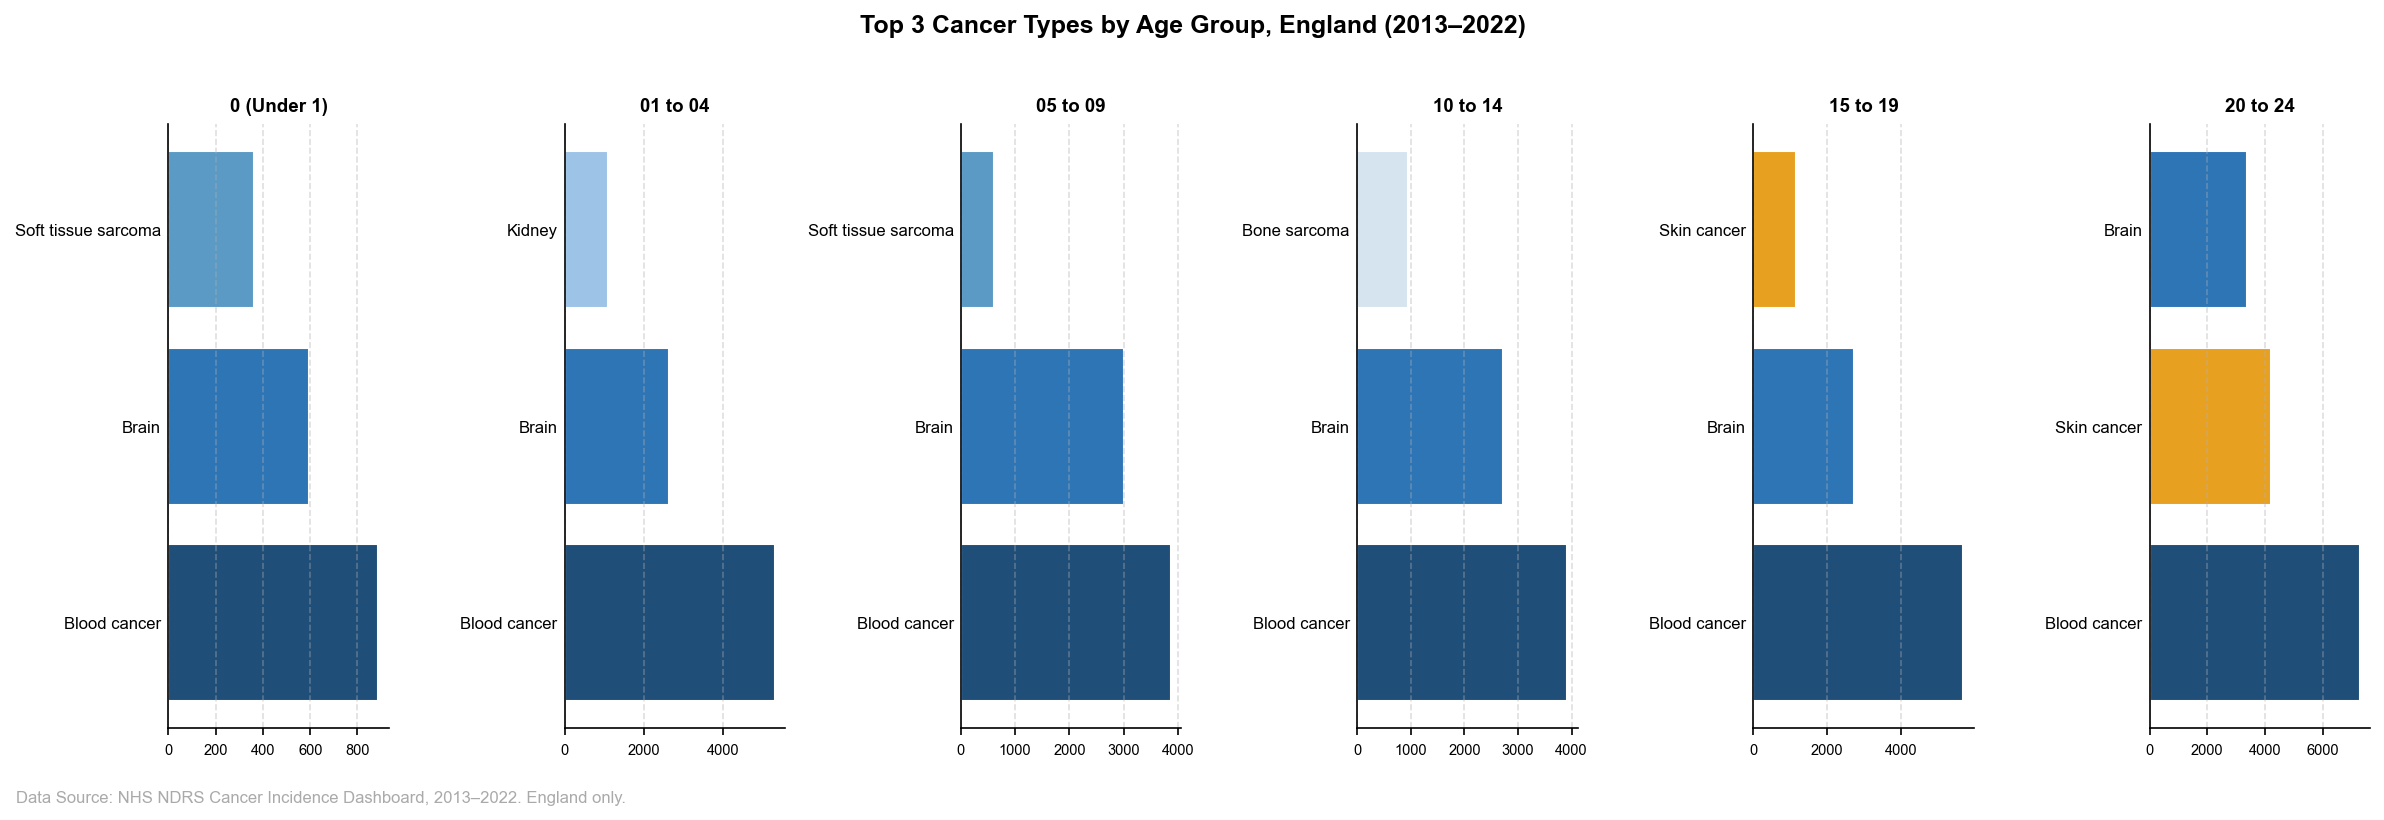

In [8]:
# Define age group order
age_order = [
    "0 (Under 1)", "01 to 04", "05 to 09",
    "10 to 14", "15 to 19", "20 to 24"
]

# Assign consistent colours to cancer types that appear across groups
cancer_types = top3_by_age["NDRS main"].unique()
colour_map = {
    cancer: colour for cancer, colour in zip(
        cancer_types,
        [NAVY, TEAL, "#5A9AC5", "#9DC3E6", "#D6E4F0", "#E8A020"]
    )
}

fig, axes = plt.subplots(
    1, 6,
    figsize=(16, 5),
    sharey=False
)

for i, age_group in enumerate(age_order):
    ax = axes[i]
    data = top3_by_age[top3_by_age["Age at diagnosis"] == age_group]

    colours = [colour_map.get(ct, GREY) for ct in data["NDRS main"]]

    ax.barh(
        data["NDRS main"],
        data["total_cases"],
        color=colours,
        edgecolor="white"
    )

    ax.set_title(age_group, fontsize=9, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8, length=0)
    ax.tick_params(axis="x", labelsize=7)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # Remove spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Top 3 Cancer Types by Age Group, England (2013–2022)",
    fontsize=12, fontweight="bold", y=1.02
)

fig.text(
    0.01, -0.03,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/1_3_cancer_type_composition_by_age_group.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- Blood cancer is the most common cancer type in every age group without exception, and Brain cancer ranks second in all age groups except 20–24. The composition of the third most common type shifts notably with age: Soft tissue sarcoma in infants, Kidney cancer in 1–4 years old, Bone sarcoma in 10–14 years old, and Skin cancer in the two oldest groups. The emergence of Skin cancer as the second most common type in the 20–24 group (displacing Brain cancer) represents the most striking compositional shift across the age range.

#### 1.4 (Not in use) Cancer Type stacked

- Stacked bar charts explored but excluded from final analysis - the faceted top 3 chart (Section 1.3) communicates the age composition finding more clearly without visual clutter.

In [9]:
# Pivot table - cases by cancer type and age group

age_type = (
    national_df.groupby(
        ["Age at diagnosis", "NDRS main"],
        observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

age_type_pivot = age_type.pivot(
    index="NDRS main",
    columns="Age at diagnosis",
    values="total_cases"
).fillna(0)

# Sort by total cases across all age groups (largest at bottom of stack)
age_type_pivot["total"] = age_type_pivot.sum(axis=1)
age_type_pivot = age_type_pivot.sort_values("total", ascending=True)
age_type_pivot = age_type_pivot.drop(columns="total")

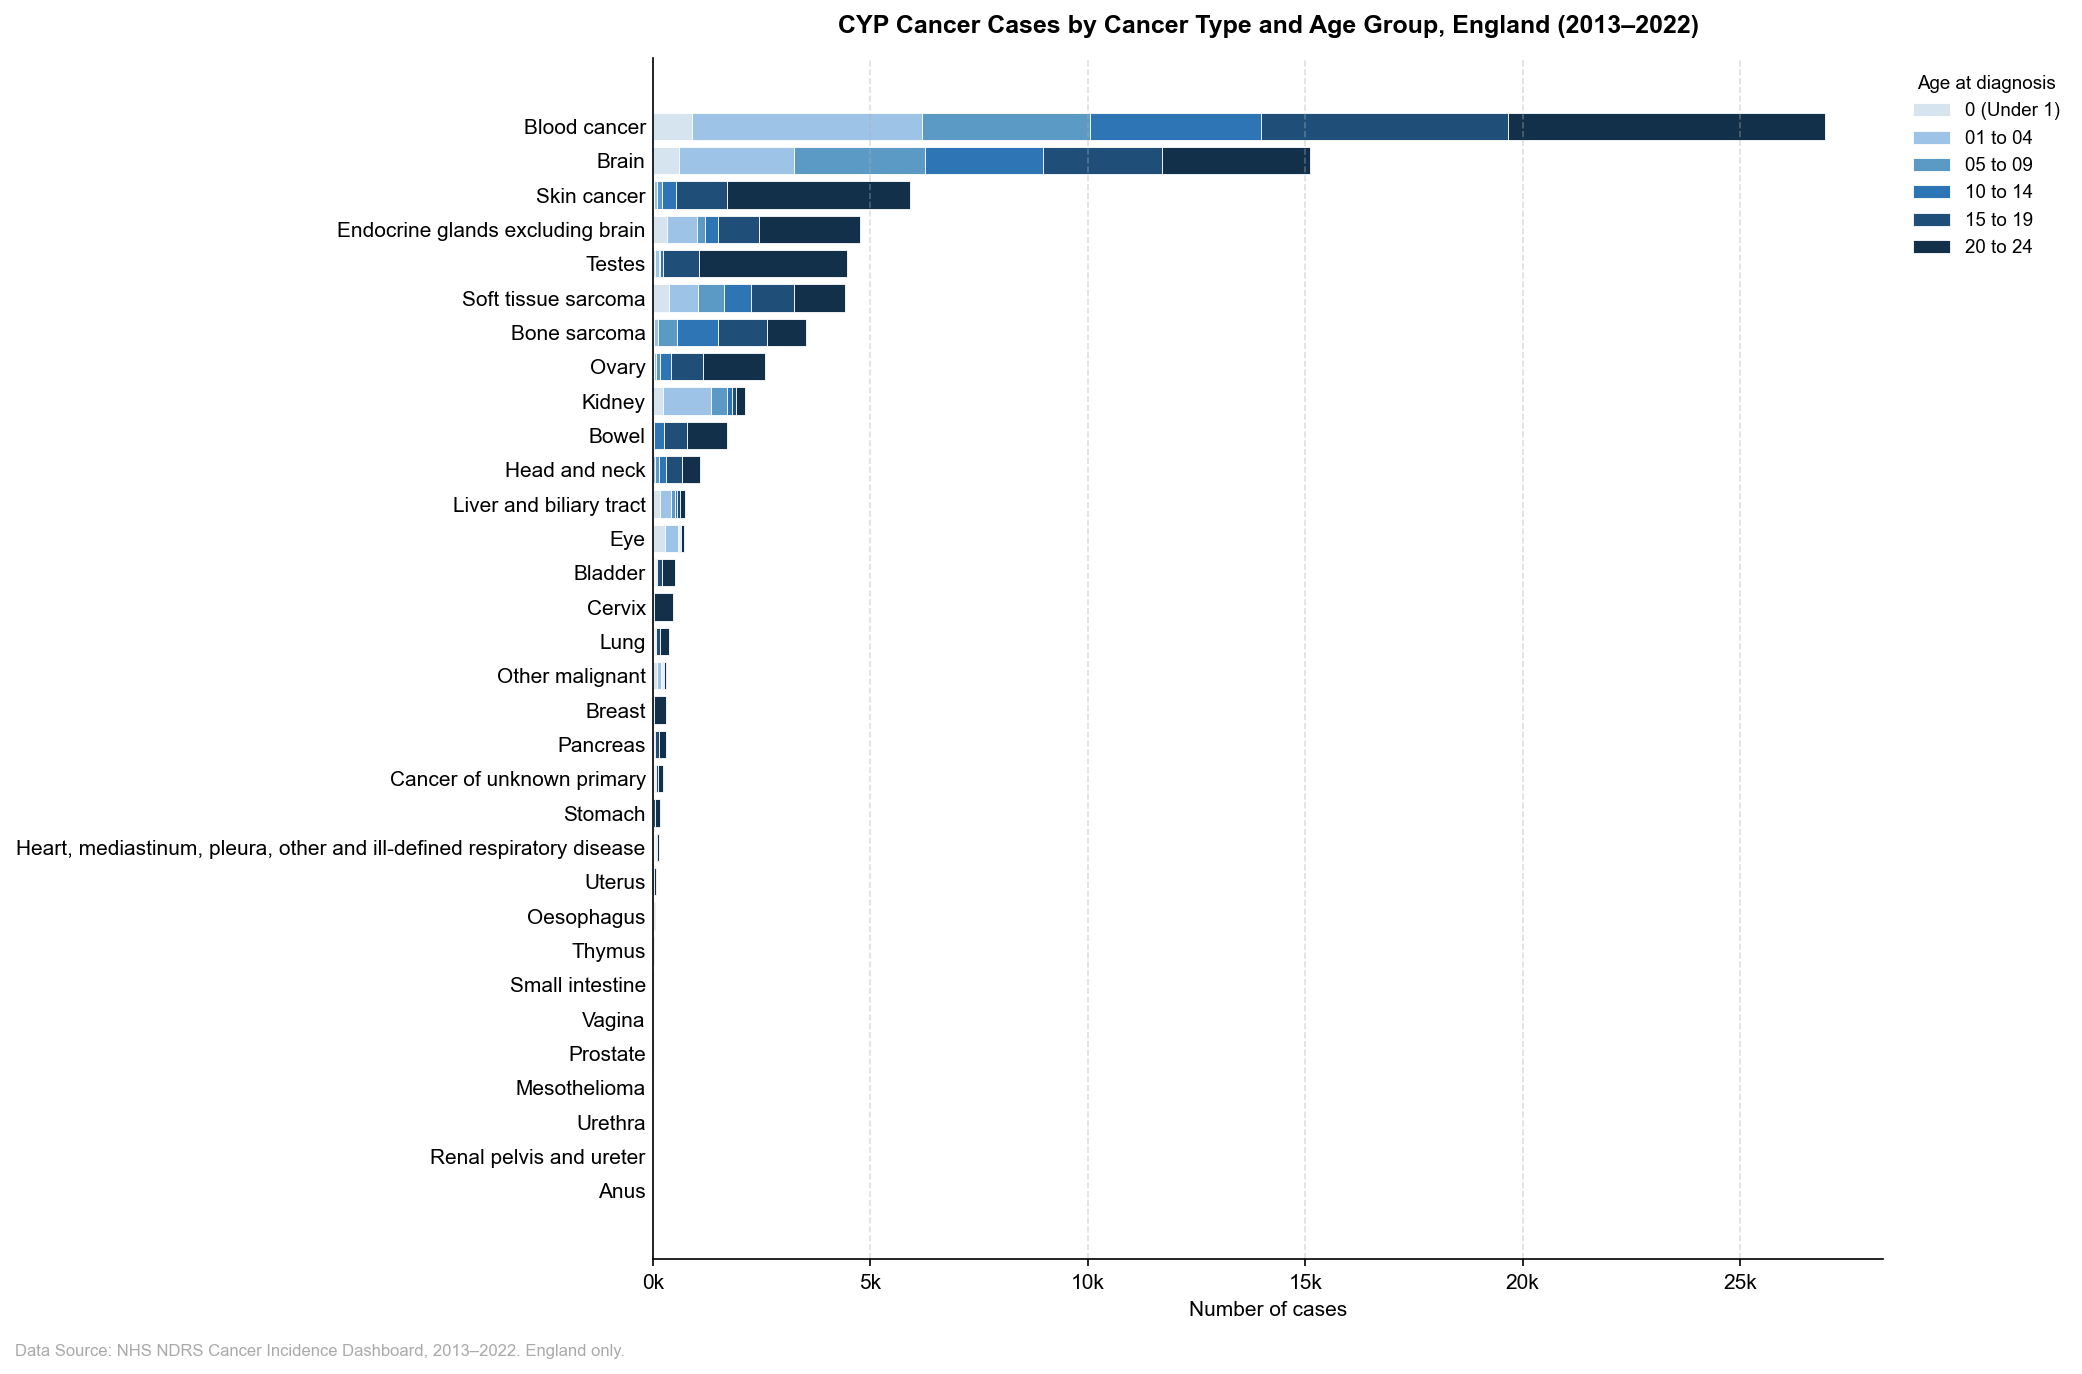

In [10]:
# Define age group order explicitly
age_order = [
    "0 (Under 1)",
    "01 to 04",
    "05 to 09",
    "10 to 14",
    "15 to 19",
    "20 to 24"
]

age_type_pivot = age_type_pivot[age_order]

# Colour palette
age_colours = [
    "#D6E4F0",  # Under 1 — lightest
    "#9DC3E6",
    "#5A9AC5",
    "#2E75B6",
    "#1F4E79",
    "#12304A"   # 20-24 — darkest
]

fig, ax = plt.subplots(figsize=(14, 9))

# Build stacked bars
bottom = pd.Series([0.0] * len(age_type_pivot), index=age_type_pivot.index)

for i, age_group in enumerate(age_order):
    ax.barh(
        age_type_pivot.index,
        age_type_pivot[age_group],
        left=bottom,
        color=age_colours[i],
        label=age_group,
        edgecolor="white",
        linewidth=0.4
    )
    bottom += age_type_pivot[age_group]

# Title and labels
ax.set_title(
    "CYP Cancer Cases by Cancer Type and Age Group, England (2013–2022)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Number of cases", fontsize=10)

# Formatting
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
)

# Legend
ax.legend(
    title="Age at diagnosis",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=9,
    frameon=False
)

ax.tick_params(axis="y", length=0)

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Data source
fig.text(
    0.01, -0.01,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.show()

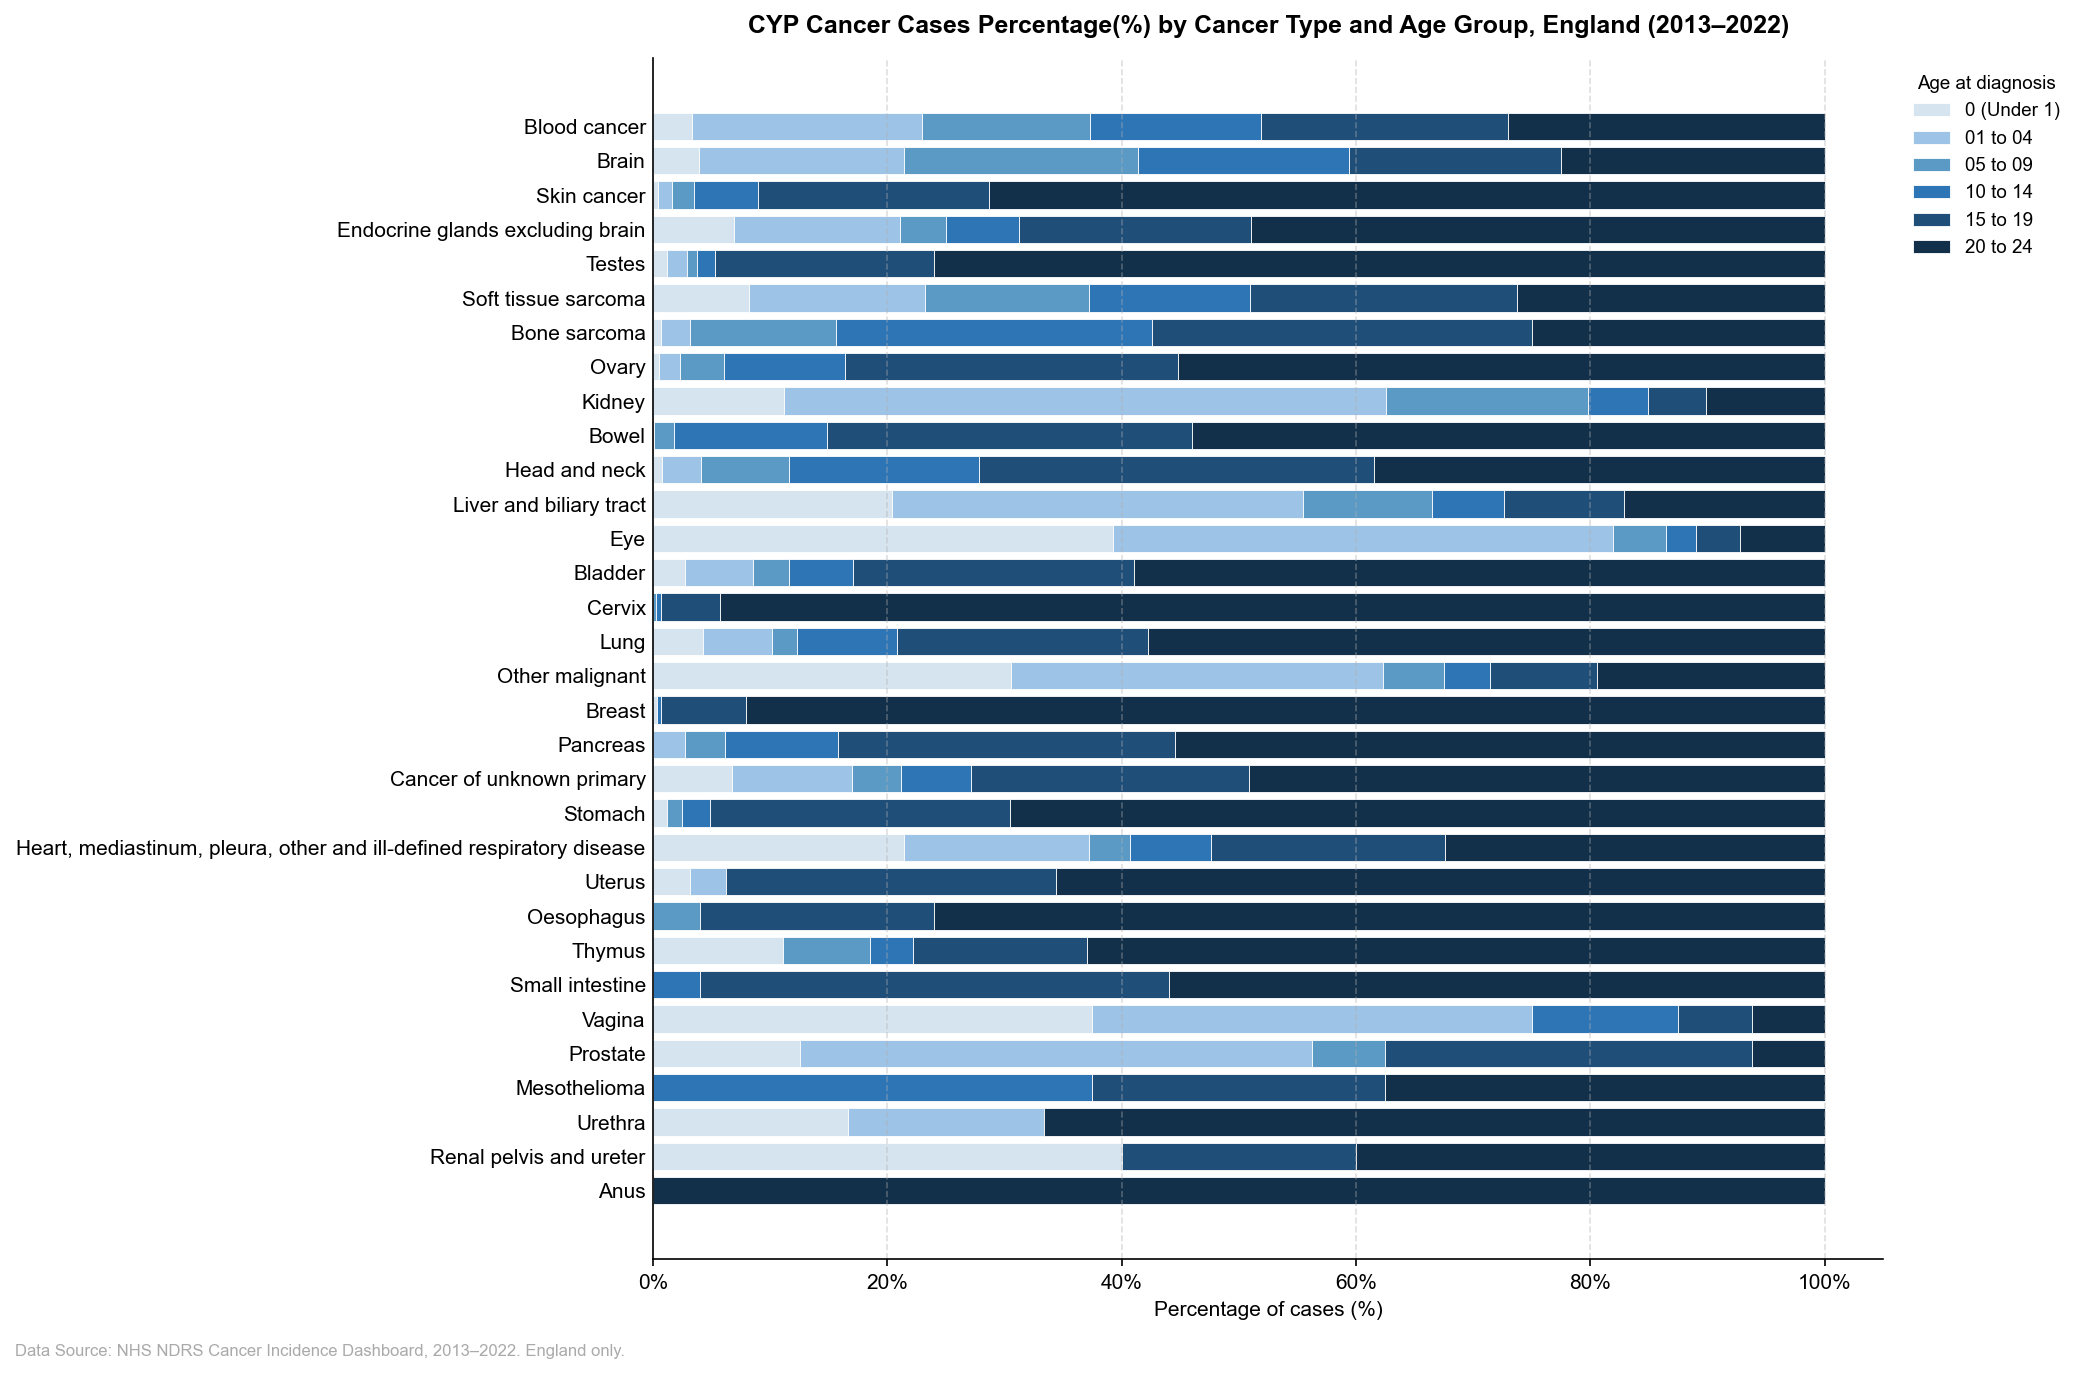

In [11]:
# Normalize to percentage
age_type_pct = age_type_pivot.div(
    age_type_pivot.sum(axis=1), axis=0
) * 100

age_type_pct = age_type_pct[age_order]

fig, ax = plt.subplots(figsize=(14, 9))

# Build stacked bars
bottom = pd.Series([0.0] * len(age_type_pct), index=age_type_pct.index)

for i, age_group in enumerate(age_order):
    ax.barh(
        age_type_pct.index,
        age_type_pct[age_group],
        left=bottom,
        color=age_colours[i],
        label=age_group,
        edgecolor="white",
        linewidth=0.4
    )
    bottom += age_type_pct[age_group]

# Title and labels
ax.set_title(
    "CYP Cancer Cases Percentage(%) by Cancer Type and Age Group, England (2013–2022)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Percentage of cases (%)", fontsize=10)

# x-axis k formatting
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x)}%")
)

# Legend
ax.legend(
    title="Age at diagnosis",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=9,
    frameon=False
)

# Remove y tick marks
ax.tick_params(axis="y", length=0)

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Data source
fig.text(
    0.01, -0.01,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.show()

### 2. Geographic Variation

- Total cases by region
- Population-adjusted rates by region
- Count rank vs rate rank comparison

#### 2.1 Total Cases by Region

In [12]:
# Plot data

regional_total_cases = (
    regional_df
    .groupby(
        "Geography name", observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .sort_values("total_cases", ascending=False)
    .reset_index()
)

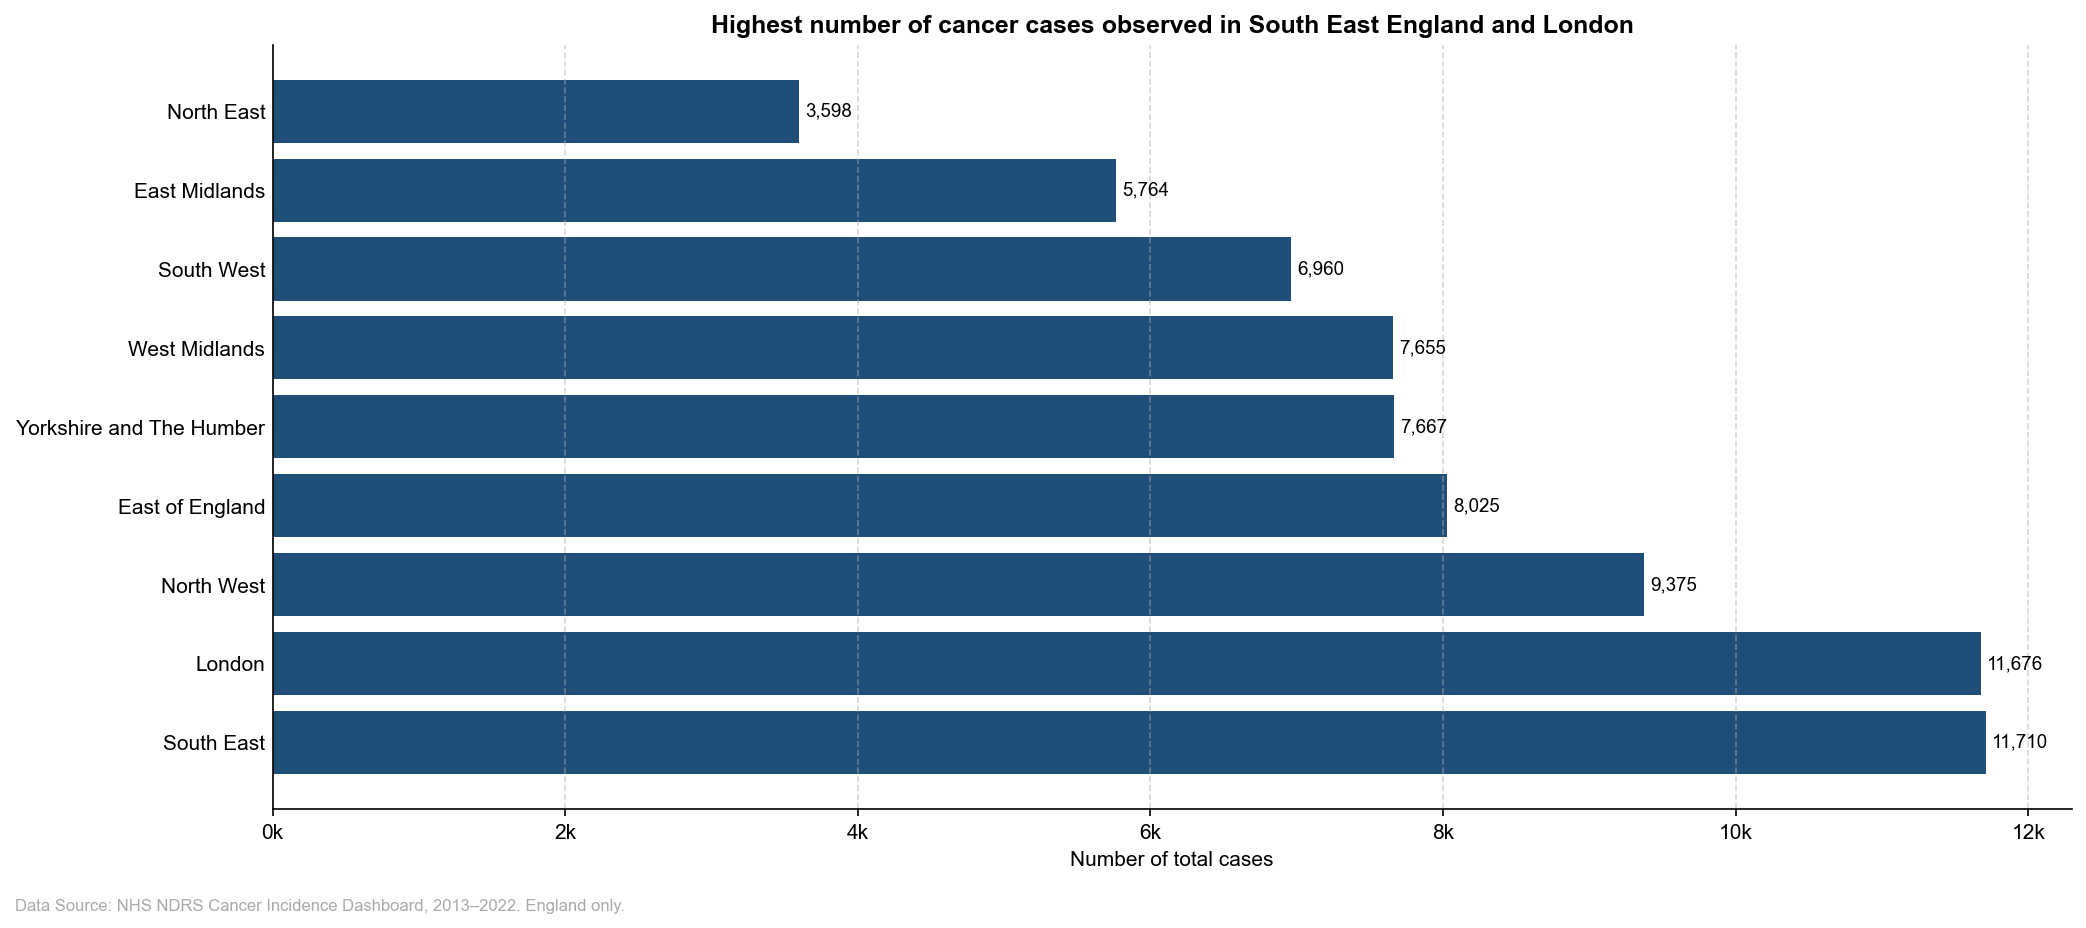

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    regional_total_cases["Geography name"],
    regional_total_cases["total_cases"],
    color=NAVY,
)

# Title and Labels
ax.set_title("Highest number of cancer cases observed in South East England and London", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of total cases", fontsize=10)
fig.text(
    0.01, -0.02,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8,
    color=GREY,
    transform=fig.transFigure
)

# Formats
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/2_1_total_case_by_region.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- South East England and London recorded the highest total CYP cancer case counts over the 2013–2022 period, with 11,710 and 11,676 cases respectively. The North East recorded the fewest cases at 3,598 — less than a third of the South East total.
- However, these figures reflect regional population sizes as much as underlying cancer burden. The following section adjusts for population to provide a fairer comparison.

#### 2.2 Population-adjusted rates by region

In [14]:
# Plot data

regional_avg_rate = (
    icd10_df
    .groupby(
        "Geography name", observed=True
    )
    .agg(
        avg_rate_per_100k=("Rate (numeric)", "mean")
    )
    .sort_values("avg_rate_per_100k", ascending=False)
    .reset_index()
)

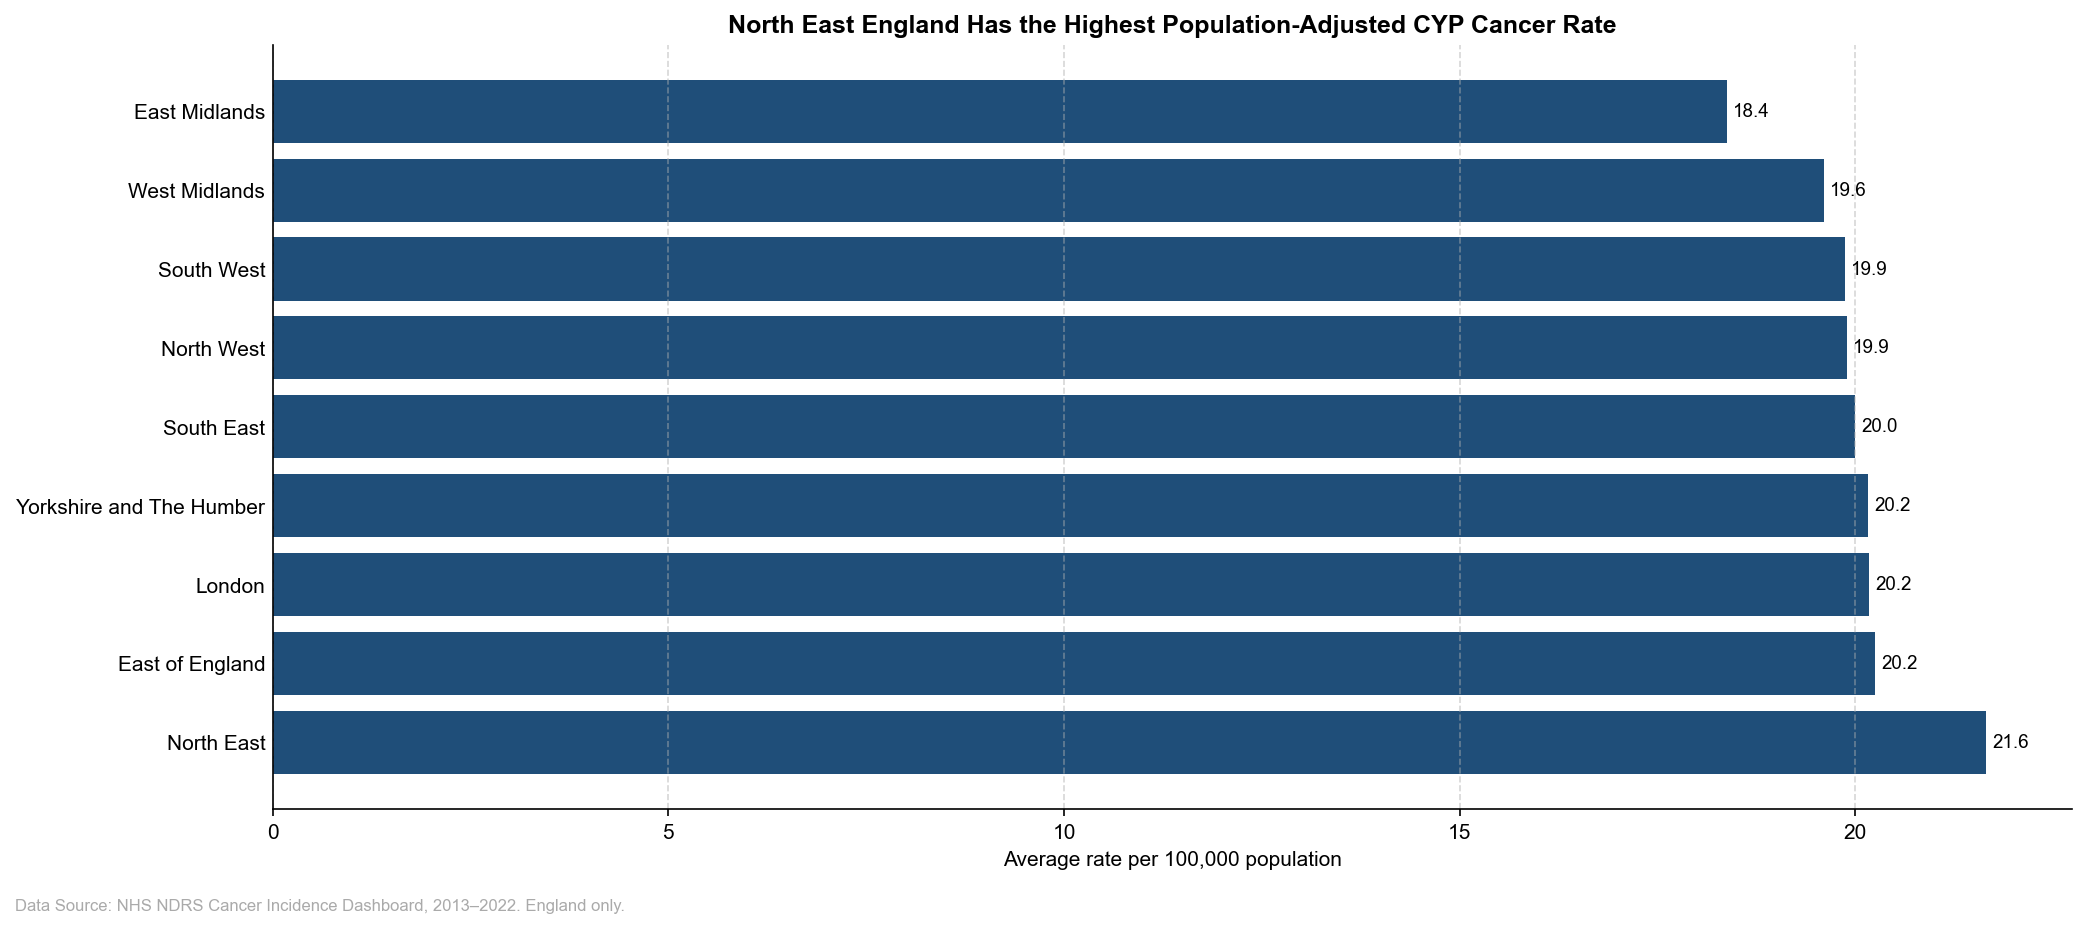

In [15]:
# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    regional_avg_rate["Geography name"],
    regional_avg_rate["avg_rate_per_100k"],
    color=NAVY,
)

# Title and Labels
ax.set_title("North East England Has the Highest Population-Adjusted CYP Cancer Rate", fontsize=12, fontweight="bold")
ax.set_xlabel("Average rate per 100,000 population", fontsize=10)
fig.text(
    0.01, -0.02,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8,
    color=GREY,
    transform=fig.transFigure
)

# Formats
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.bar_label(bars, fmt="{:,.1f}", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x)}")
)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/2_2_population_adjusted_rate_by_region.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- When adjusted for population size, the regional picture reverses substantially. The North East has the highest average age-specific incidence rate at 21.6 cases per 100,000 population aged 0–24 — the region that ranked last by raw case count. East of England ranks second at 20.3, and East Midlands ranks lowest at 18.4.
- The overall range across regions is narrow (approximately 3.2 per 100,000), suggesting that while differences exist, CYP cancer incidence does not vary dramatically across NHS England regions once population is accounted for.

#### 2.3 Count rank vs rate rank comparison

In [16]:
# Plot data

rank_comparison = regional_total_cases.merge(regional_avg_rate)

rank_comparison = rank_comparison.sort_values(
    "total_cases", ascending=True
).reset_index(drop=True)

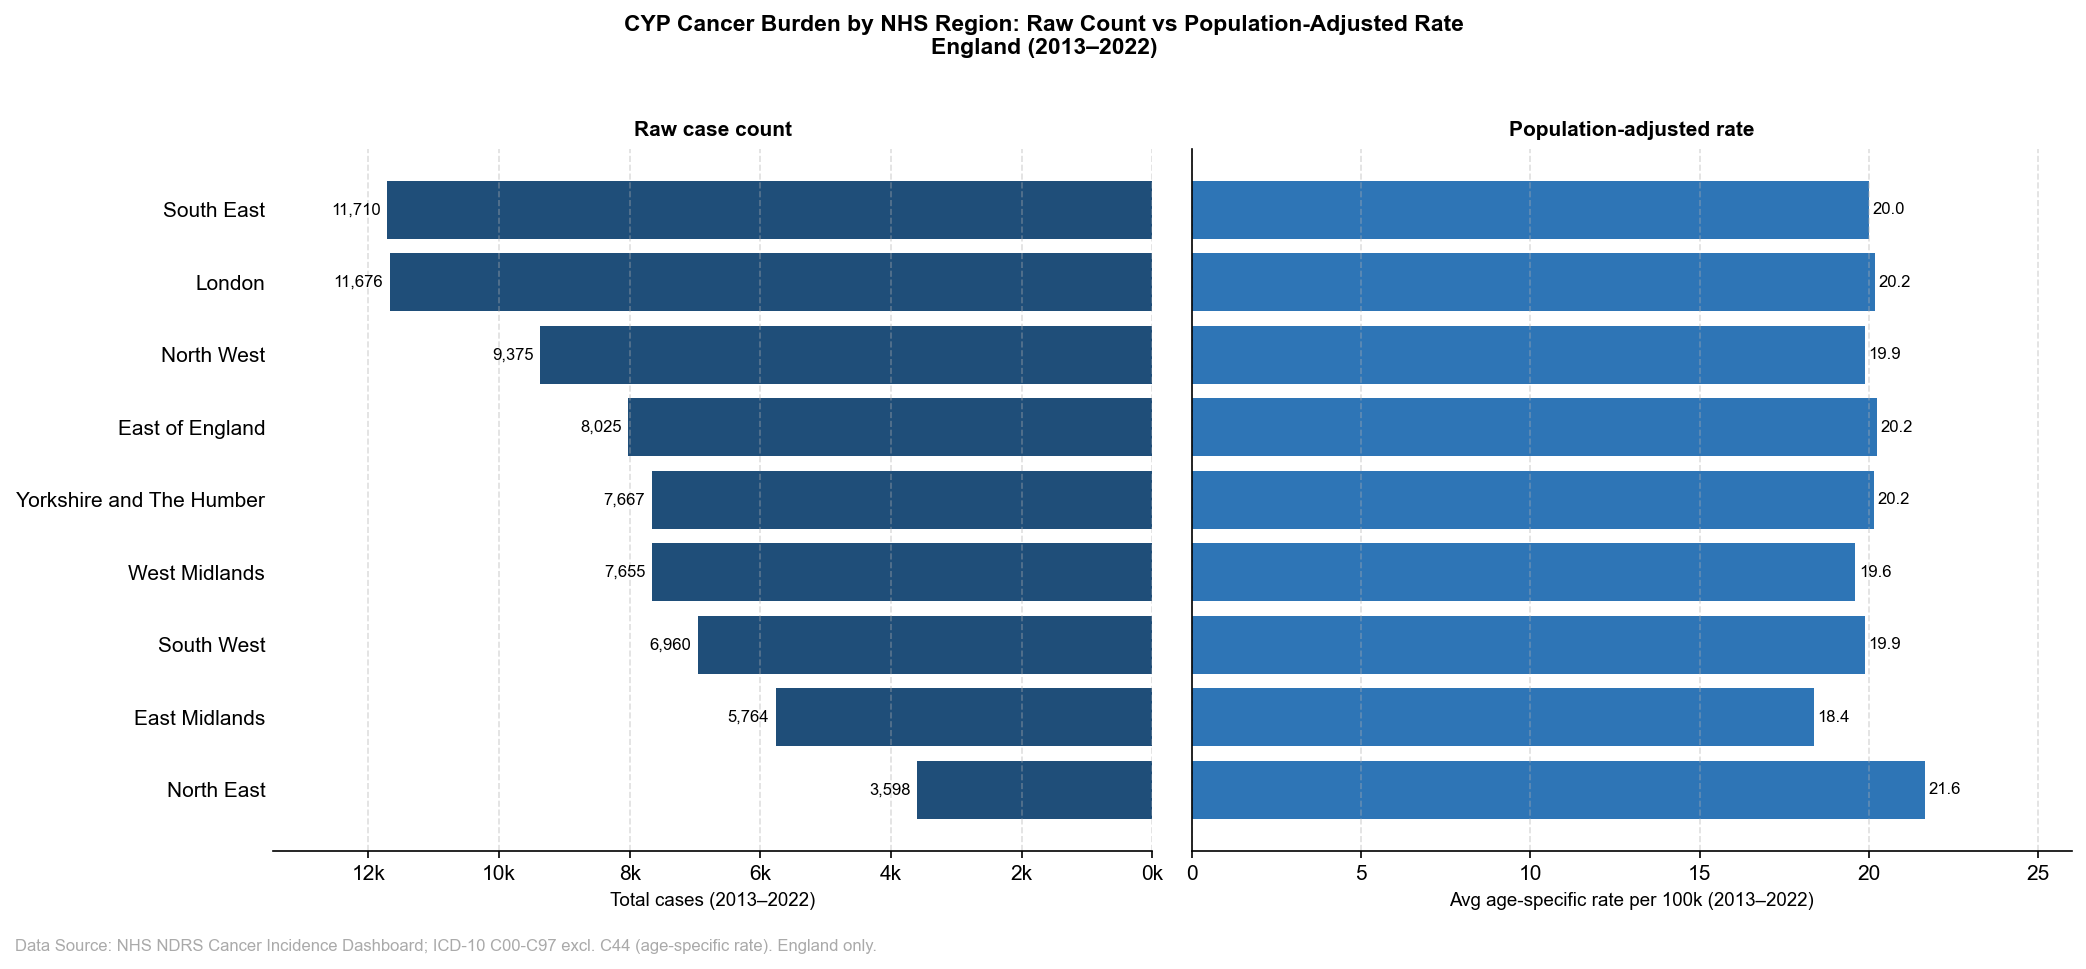

In [17]:
# Define regions, counts, and rates
regions = rank_comparison["Geography name"]
counts = rank_comparison["total_cases"]
rates = rank_comparison["avg_rate_per_100k"]

fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True
)

# Left panel: total cases
ax_left.barh(regions, counts, color=NAVY)
ax_left.set_xlim(counts.max() * 1.15, 0)   # reversed x-axis
ax_left.set_xlabel("Total cases (2013–2022)", fontsize=9)
ax_left.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
)
ax_left.tick_params(axis="y", length=0)
ax_left.grid(axis="x", linestyle="--", alpha=0.4)
ax_left.spines["top"].set_visible(False)
ax_left.spines["left"].set_visible(False)

# Add value labels on left bars
for i, val in enumerate(counts):
    ax_left.text(
        val + 100, i, f"{val:,.0f}",
        va="center", ha="right", fontsize=8
    )

# Right panel: population-adjusted rate
ax_right.barh(regions, rates, color=TEAL)
ax_right.set_xlim(0, rates.max() * 1.2)
ax_right.set_xlabel("Avg age-specific rate per 100k (2013–2022)", fontsize=9)
ax_right.tick_params(axis="y", length=0)
ax_right.grid(axis="x", linestyle="--", alpha=0.4)
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)

# Add value labels on right bars
for i, val in enumerate(rates):
    ax_right.text(
        val + 0.1, i, f"{val:.1f}",
        va="center", ha="left", fontsize=8
    )

ax_left.yaxis.set_tick_params(labelleft=True)

# Titles
ax_left.set_title("Raw case count", fontsize=10, fontweight="bold")
ax_right.set_title("Population-adjusted rate", fontsize=10, fontweight="bold")

fig.suptitle(
    "CYP Cancer Burden by NHS Region: Raw Count vs Population-Adjusted Rate\n"
    "England (2013–2022)",
    fontsize=11, fontweight="bold", y=1.02
)

fig.text(
    0.01, -0.02,
    "Data Source: NHS NDRS Cancer Incidence Dashboard; "
    "ICD-10 C00-C97 excl. C44 (age-specific rate). England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/2_3_count_ranking_rate_ranking_comparison.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- The comparison between raw case count rank and population-adjusted rate rank reveals important differences. The North East shows the most dramatic divergence — rank 9 by case count but rank 1 by population-adjusted rate, a difference of 8 positions. South East shows the reverse pattern — rank 1 by case count but rank 5 by rate.
- This finding demonstrates that raw case counts are a poor proxy for cancer burden in smaller regions, and that population adjustment is essential for meaningful regional comparison.
- The narrow rate range across all regions (18.4–21.6 per 100,000) suggests that most regional variation in case counts is explained by population size rather than genuine differences in cancer incidence.

### 3. Trend Analysis

- National trend
- Cancer type trend
- Regional trend
- Regional rate trend

#### 3.1 National Trend

In [18]:
# Total cases by year - 2013 to 2022

# Plot data
cases_by_year = (
    national_df
    .groupby(
        "Year",
        observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

cases_by_year

,Year,total_cases
0,2013,7802
1,2014,8128
2,2015,8207
3,2016,7788
4,2017,7723
5,2018,7407
6,2019,7692
7,2020,7202
8,2021,7486
9,2022,7601


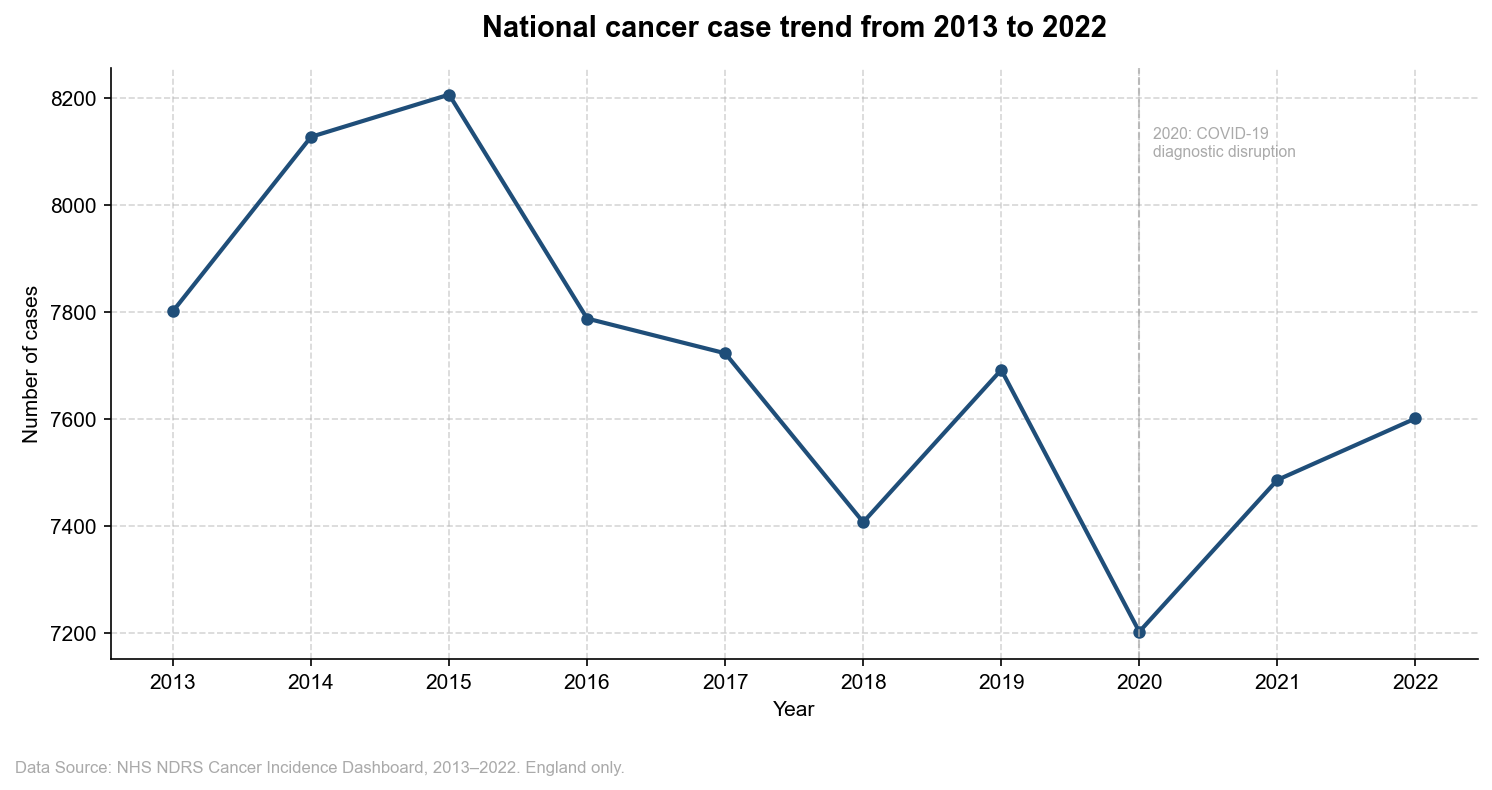

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    cases_by_year["Year"],
    cases_by_year["total_cases"],
    marker="o",
    markersize=5,
    linewidth=2,
    color=NAVY,
)

ax.set_title("National cancer case trend from 2013 to 2022", fontsize=14, pad=15, weight="bold")

ax.set_ylabel("Number of cases")

# x-axis
ax.set_xlabel("Year")
ax.set_xticks(range(2013,2023))
ax.grid(axis="both", linestyle="--", alpha=0.5)

# annotation
ax.axvline(x=2020, color=GREY, linestyle="--", linewidth=1, alpha=0.7)
ax.text(
    2020.1, ax.get_ylim()[1] * 0.98,
    "2020: COVID-19\ndiagnostic disruption",
    fontsize=7.5, color=GREY
)

# Data source
fig.text(
    0.01, -0.04,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/3_1_overall_national_trend.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- National CYP cancer case counts were broadly stable between 2013 and 2022, fluctuating between approximately 7,200 and 8,200 cases per year. The number of cancer case diagnosed reached its peak at 2015, followed by a general decline through 2018.
- Another notable dip is visible in 2020 (-6.4% year-on-year), consistent with the disruption to cancer diagnostic services during the COVID-19 pandemic, when routine referrals and screening activities were suspended or reduced. Case counts partially recovered in 2021 and continued to recover in 2022, though they remained below the pre-pandemic 2019 level. This artefact should be considered when interpreting any trend that crosses the 2020–2021 period.

#### 3.2 Cancer Type Trend

In [20]:
# Top 6 cancer types total volume trend (cases per year)

top6_types = (
    national_df
    .groupby("NDRS main", observed=True)
    .agg(
        total_cases=("Count", "sum")
    )
    .sort_values("total_cases", ascending=False)
    .head(6)
    .index.tolist()
)

top6_trend = (
    national_df[national_df["NDRS main"].isin(top6_types)]
    .groupby(
        ["Year", "NDRS main"],
        observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

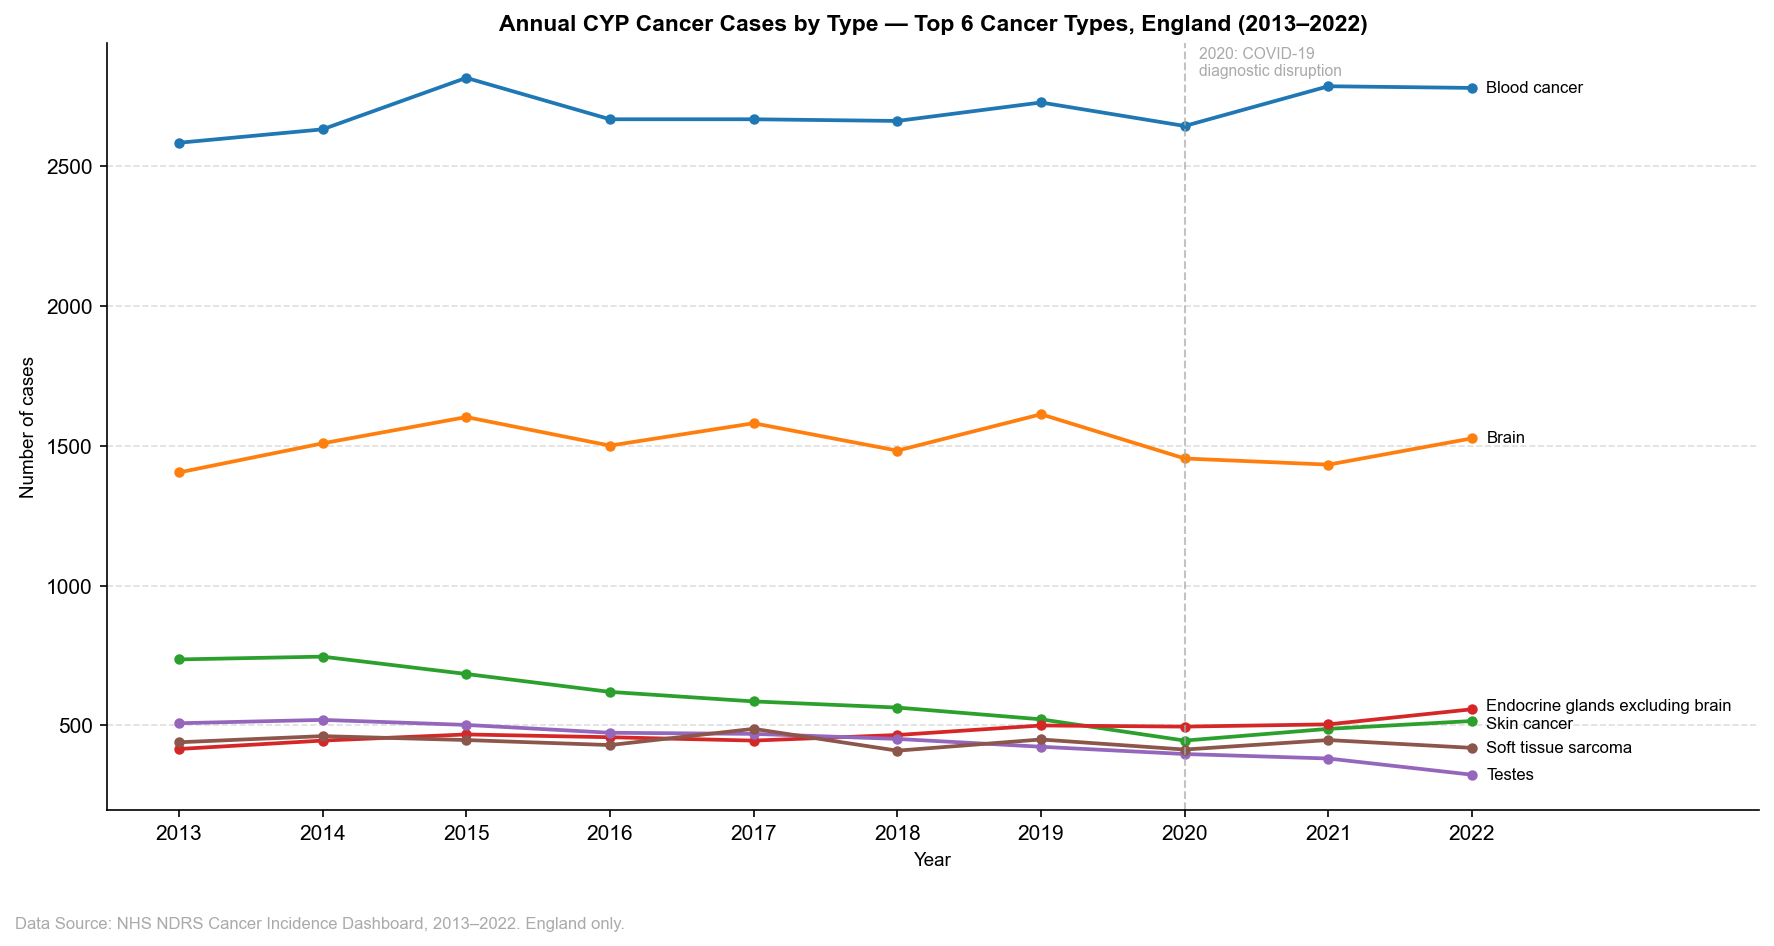

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

label_offsets = {
    "Blood cancer": 0,
    "Brain": 0,
    "Skin cancer": -10,
    "Endocrine glands excluding brain": 10,
    "Testes": 0,
    "Soft tissue sarcoma": 0,
}

for cancer_type in top6_types:
    data = top6_trend[top6_trend["NDRS main"] == cancer_type]
    ax.plot(
        data["Year"],
        data["total_cases"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=cancer_type
    )

    # Label at the end of each line
    last_row = data[data["Year"] == data["Year"].max()]
    offset = label_offsets.get(cancer_type, 0)

    ax.text(
        last_row["Year"].values[0] + 0.1,
        (last_row["total_cases"].values[0]) + offset,
        cancer_type,
        fontsize=8,
        va="center"
    )

# Title and labels
ax.set_title(
    "Annual CYP Cancer Cases by Type — Top 6 Cancer Types, England (2013–2022)",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Year", fontsize=9)
ax.set_ylabel("Number of cases", fontsize=9)

# x-axis
ax.set_xticks(range(2013, 2023))
ax.set_xlim(2012.5,2024)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No legend
ax.get_legend().remove() if ax.get_legend() else None

# COVID annotation
ax.axvline(x=2020, color=GREY, linestyle="--", linewidth=1, alpha=0.7)
ax.text(
    2020.1, ax.get_ylim()[1] * 0.96,
    "2020: COVID-19\ndiagnostic disruption",
    fontsize=7.5, color=GREY
)

# Data source
fig.text(
    0.01, -0.04,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/3_2_top_6_cancer_type_trend.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- Trend patterns vary considerably across the top six cancer types. Skin cancer showed a notable downward trend, recording 220 fewer cases in 2022 than in 2013, the largest absolute decline of any cancer type.
- Blood cancer showed the largest absolute increase (+196 cases). All six types show a visible 2020 dip consistent with COVID-19 diagnostic disruption.

#### 3.3 Regional Trend

In [22]:
# total cases per year by region (9 lines)

regional_trend = (
    regional_df
    .groupby(
        ["Year", "Geography name"],
        observed=True
    )
    .agg(
        total_cases=("Count", "sum")
    )
    .reset_index()
)

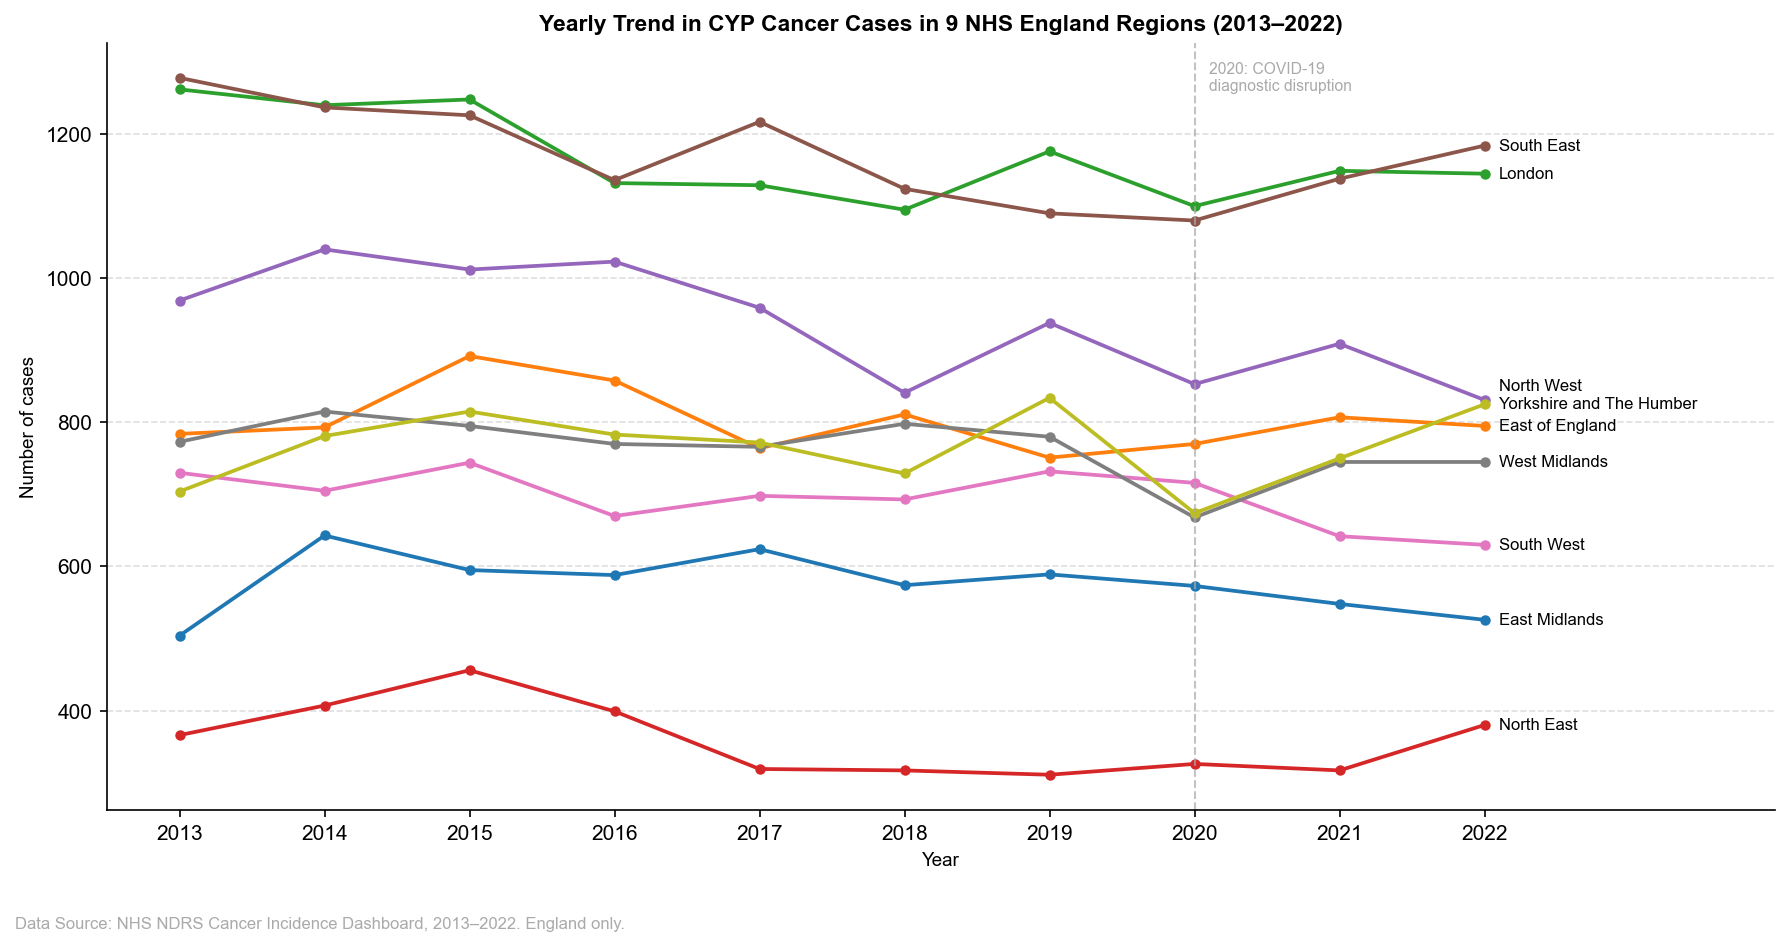

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

regions = list(regional_df["Geography name"].unique())

label_offsets_regional = {
    "South East": 0,
    "London": 0,
    "North West": 20,
    "East of England": 0,
    "Yorkshire and The Humber": 0,
    "West Midlands": 0,
    "South West": 0,
    "East Midlands": 0,
    "North East": 0,
}

for region in regions:
    data = regional_trend[regional_trend["Geography name"] == region]
    offset = label_offsets_regional.get(region, 0)

    ax.plot(
        data["Year"],
        data["total_cases"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=region
    )

    # Label at the end of each line
    last_row = data[data["Year"] == data["Year"].max()]
    ax.text(
        last_row["Year"].values[0] + 0.1,
        (last_row["total_cases"].values[0]) + offset,
        region,
        fontsize=8,
        va="center"
    )

# Title and labels
ax.set_title(
    "Yearly Trend in CYP Cancer Cases in 9 NHS England Regions (2013–2022)",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Year", fontsize=9)
ax.set_ylabel("Number of cases", fontsize=9)

# x-axis
ax.set_xticks(range(2013, 2023))
ax.set_xlim(2012.5, 2024)

# COVID annotation
ax.axvline(x=2020, color=GREY, linestyle="--", linewidth=1, alpha=0.7)
ax.text(
    2020.1, ax.get_ylim()[1] * 0.95,
    "2020: COVID-19\ndiagnostic disruption",
    fontsize=7.5, color=GREY
)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No legend
ax.get_legend().remove() if ax.get_legend() else None

# Data source
fig.text(
    0.01, -0.04,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, 2013–2022. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/3_3_regional_case_trend.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- Regional case count trends were broadly parallel across all nine NHS England regions between 2013 and 2022, with all regions showing the characteristic 2020 dip and subsequent recovery.
- South East and London consistently recorded the highest annual case counts throughout the period, while the North East remained consistently lowest.
- Yorkshire and The Humber showed the most notable relative increase in cases, rising from rank 7 in 2013 to rank 4 in 2022 — though this shift in ranking may partly reflect differential population growth across regions rather than a genuine change in cancer burden.

#### 3.4 Regional Rate Trend

In [24]:
# Regional-rate-trend

regional_rate_trend = (
    icd10_df
    .groupby(
        ["Year", "Geography name"],
        observed=True
    )
    .agg(
        avg_rate=("Rate (numeric)", "mean")
    )
    .reset_index()
)

regional_rate_trend_pivot = regional_rate_trend.pivot(
    index="Geography name",
    columns="Year",
    values="avg_rate"
)

regional_rate_trend_pivot

Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Geography name,,,,,,,,,,
East Midlands,17.2,20.6,19.4,18.0,20.4,17.8,18.2,17.9,17.3,17.0
East of England,18.9,20.2,22.7,21.4,18.6,20.4,19.7,20.0,21.1,19.5
London,21.8,21.8,21.9,18.8,19.0,18.6,20.5,19.2,20.2,19.9
North East,22.0,25.6,27.4,23.5,20.2,19.5,18.4,19.7,19.4,20.8
North West,20.8,21.5,21.6,21.6,20.1,17.8,20.9,18.2,19.3,17.1
South East,21.8,20.4,21.0,19.4,21.0,19.4,18.6,19.3,18.9,20.2
South West,20.6,20.9,20.6,19.8,19.6,19.8,20.2,20.6,18.9,17.7
West Midlands,20.9,20.0,20.3,19.8,18.9,20.1,20.0,17.3,19.4,19.3
Yorkshire and The Humber,19.0,22.4,22.4,21.5,19.8,18.6,20.1,18.1,18.6,21.1


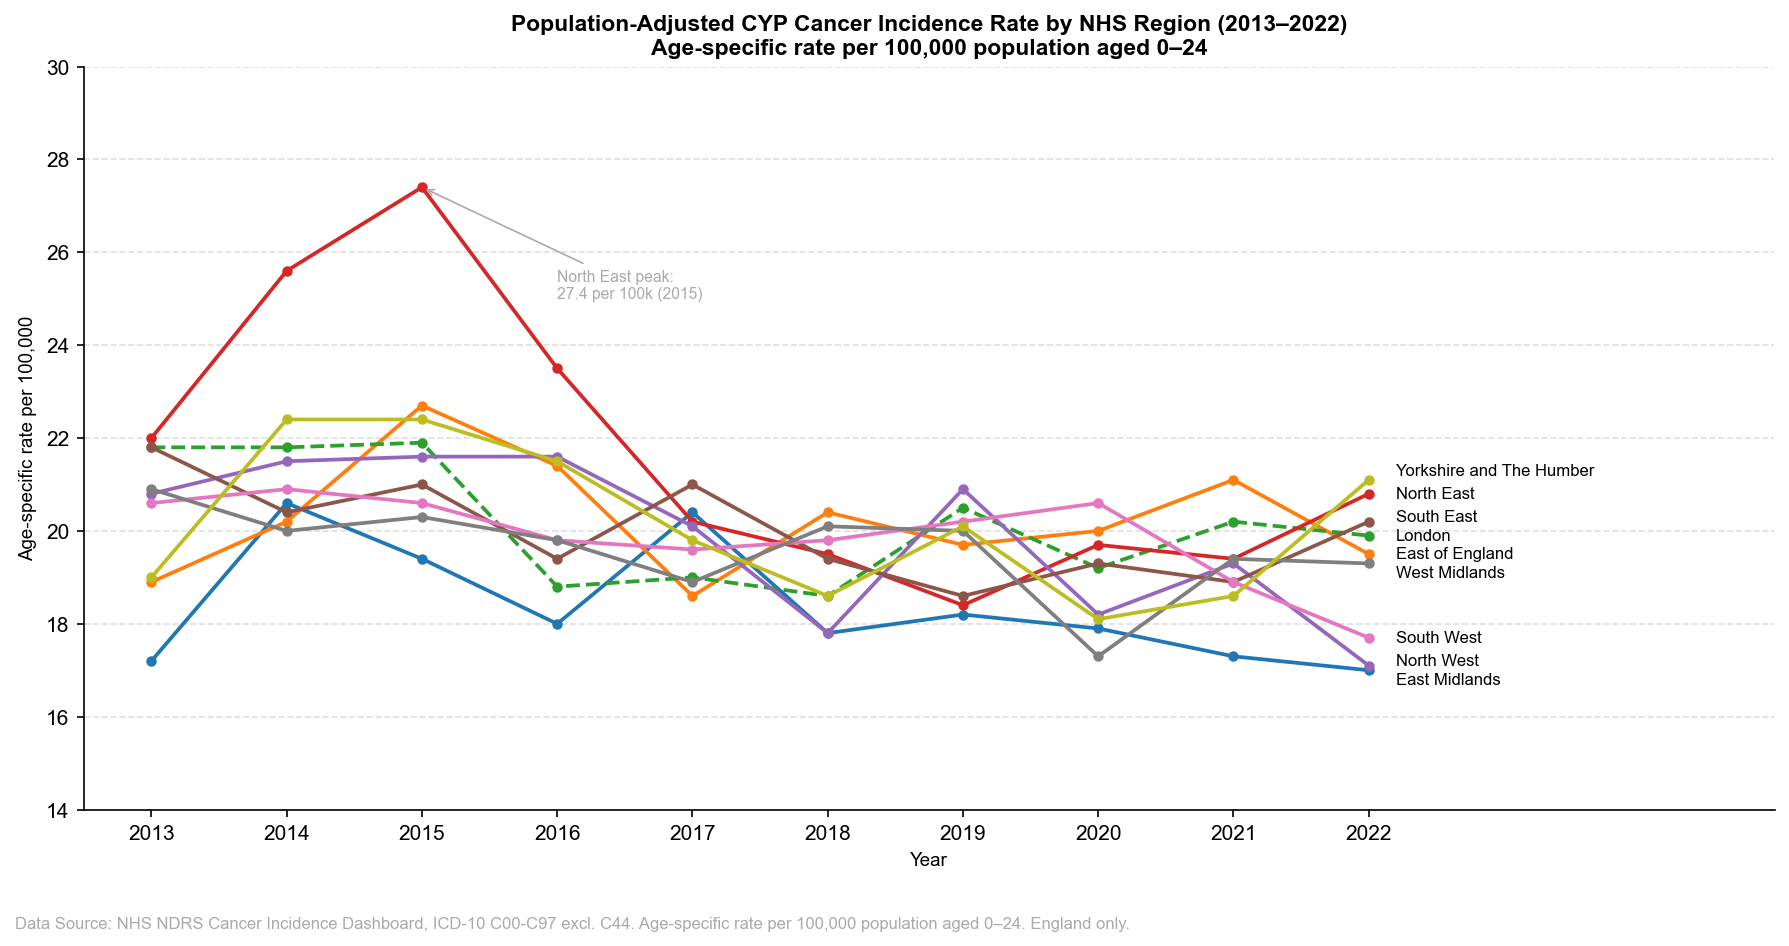

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

regions_list = regional_rate_trend["Geography name"].unique()

label_offsets_regional_rate = {
    "South East": 0.1,
    "London": 0,
    "North West": 0.1,
    "East of England": 0,
    "Yorkshire and The Humber": 0.2,
    "West Midlands": -0.2,
    "South West": 0,
    "East Midlands": -0.2,
    "North East": 0,
}

for region in regions_list:
    data = regional_rate_trend[
        regional_rate_trend["Geography name"] == region
    ]
    linestyle = "--" if region == "London" else "-"
    offset = label_offsets_regional_rate.get(region, 0)
    ax.plot(
        data["Year"],
        data["avg_rate"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        linestyle=linestyle,
        label=region
    )

    last_row = data[data["Year"] == 2022]
    ax.text(
        2022.2,
        (last_row["avg_rate"].values[0]) + offset,
        region,
        fontsize=8,
        va="center"
    )

# North East 2015 peak annotation
ax.annotate(
    "North East peak:\n27.4 per 100k (2015)",
    xy=(2015, 27.4),
    xytext=(2016, 25),
    fontsize=7.5,
    color=GREY,
    arrowprops=dict(arrowstyle="->", color=GREY, lw=0.8)
)

ax.set_title(
    "Population-Adjusted CYP Cancer Incidence Rate by NHS Region (2013–2022)\n"
    "Age-specific rate per 100,000 population aged 0–24",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Year", fontsize=9)
ax.set_ylabel("Age-specific rate per 100,000", fontsize=9)
ax.set_xticks(range(2013, 2023))
ax.set_xlim(2012.5, 2025)
ax.set_ylim(14, 30)   # give headroom for North East peak

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01, -0.04,
    "Data Source: NHS NDRS Cancer Incidence Dashboard, ICD-10 C00-C97 excl. C44. "
    "Age-specific rate per 100,000 population aged 0–24. England only.",
    fontsize=8, color=GREY
)

plt.tight_layout()
plt.savefig(
    "../3_output/3_images/3_4_regional_rate_trend.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

- Population-adjusted incidence rates show greater year-to-year variability than raw case counts, reflecting the sensitivity of rates to small absolute changes in case numbers — particularly in smaller regions such as the North East. The North East shows the highest peak rate in the dataset at 27.4 per 100,000 in 2015, followed by a decline to 18.4 in 2019, before recovering toward 2022. This volatility is partly a function of small population size, where individual-year counts can fluctuate meaningfully.

- Across the full 2013–2022 period, East Midlands consistently recorded the lowest rates, while the North East and Yorkshire and The Humber showed higher volatility than southern regions. Notably, the spread between regional rates appears narrower in the 2018–2022 period compared to 2013–2016, which may indicate a gradual convergence in population-adjusted CYP cancer burden across NHS England regions — though the small numbers and year-to-year noise make this a tentative observation requiring longer-term data to confirm.

- These rate-based trends complement the raw case count trends in Section 3.3. While Section 3.3 showed South East and London consistently leading in case volume, the rate-based view in this section shows no single region consistently elevated above others — reinforcing the conclusion that raw case count differences between regions are largely explained by population size rather than genuine differences in cancer risk.

### 4. Key Findings Summary

**Age profiles and cancer type composition**
- Blood cancer accounts for 35.0% of all CYP cancer cases in England between 2013 and 2022, followed by Brain cancer at 19.6%. Together these two types represent over half of all CYP cancer burden.
- Cancer incidence rises sharply with age within the 0–24 group: the 20–24 age group accounts for 35.9% of all cases, nearly double the next largest group (15–19 at 20.6%).
- The composition of cancer types changes substantially across age groups. Blood cancer and Brain cancer dominate in all age groups, but the third most common type shifts from Soft tissue sarcoma in infants to Kidney cancer in 1–4 year olds, Bone sarcoma in 10–14 year olds, and Skin cancer in young adults aged 15–24.

**Geographic variation**
- Raw case counts are highest in South East England and London (11,710 and 11,676 respectively), reflecting their large populations. The North East recorded the fewest cases at 3,598.
- When adjusted for population size, the picture reverses substantially. The North East has the highest age-specific incidence rate (21.6 per 100,000), while East Midlands has the lowest (18.4 per 100,000). The overall range across regions is narrow (3.2 per 100,000), suggesting that most variation in raw case counts is explained by population size rather than genuine differences in cancer risk.

**Trends 2013–2022**
- National CYP cancer case counts were broadly stable, fluctuating between approximately 7,200 and 8,200 cases per year. A 6.4% decline in 2020 is consistent with COVID-19 diagnostic disruption, with partial recovery by 2022 remaining below pre-pandemic levels.
- Skin cancer showed the largest absolute decline across the period (-220 cases comparing 2013 to 2022), while blood cancer showed the largest increase (+196 cases).
- Regional case count trends were broadly parallel. Population-adjusted rate trends show greater year-to-year variability, with the North East reaching a peak rate of 27.4 per 100,000 in 2015 before declining. The spread between regional rates appears to narrow post-2018, tentatively suggesting convergence in CYP cancer burden across regions.

### 5. Limitations and Methodological Notes

**Count-based analysis throughout** 
- National and regional NDRS analysis uses case counts rather than rates due to high suppression (11,869 of 15,480 national records and 13,292 of 18,090 regional records have suppressed rates). Counts are influenced by population size and should not be used to make direct comparisons between regions of different sizes without adjustment — please refer to Section 2.3 for population-adjusted comparison.

**Regional boundaries**
- Regional analysis uses pre-2019 NHS England legacy boundaries (nine regions). These differ from the current seven NHS England regions introduced in April 2019. Direct comparison with publications using the current boundary structure should be made with caution.

**ICD-10 and NDRS classification systems**
- Population-adjusted rate analysis (Sections 2.2 and 2.3) uses a supplementary dataset based on ICD-10 classification (C00-C97 excl. C44). This differs from the NDRS Cancer Group classification used in Sections 1 and 3. The two datasets are not directly comparable at cancer type level and are used for different analytical purposes: NDRS data for cancer type composition and trends, ICD-10 data for population-adjusted regional comparison only.

**COVID-19 artefact**
- A visible decline in registered cases in 2020 is observed across all cancer types and regions. This is consistent with the known disruption to cancer diagnostic pathways during the COVID-19 pandemic and likely reflects reduced diagnostic activity rather than a genuine fall in cancer incidence. Trend interpretations crossing 2020–2021 should account for this artefact.

**Ecological analysis**
- All findings describe population-level patterns at national or regional level. They cannot be used to draw conclusions about the experiences or risk factors of individual patients. The absence of patient-level data is a feature of this publicly available dataset, not a limitation of the analysis approach.

**Data lag**
- NHS cancer registration data is subject to a lag of approximately 2–3 years due to registration and coding processes. The 2022 data used here represents the most recently available figures at time of analysis but may not capture the most recent trends in incidence.